## <center> **Iris Species Segmentation** </center>
----

### Objective:

- This notebook explores and compares three popular unsupervised machine learning algorithms, `K-Means`, `Agglomarative Hierarchical Clustering`, and `DBSCAN`, Using the famous iris dataset.
- The objective is to identify natural groupings within the data without using the target labels. The performance of each clustering algorithm is avaluated using the `silhouette score`, which measures how well data points fit within their assigned clusters. 
- By comparing results, we can determine which clustering technique is most effective for the iris dataset.

---

### Step 01: Import libraries

In [26]:
import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt 
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

from kneed import KneeLocator

### Step 02: Load dataset

In [2]:
iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns= iris.feature_names
)

print(X.shape)
X.head()

(150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Step 03: Visualize original datset

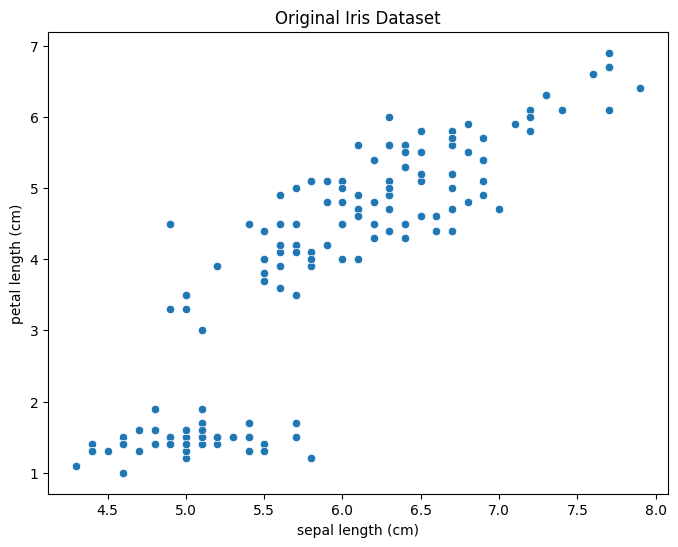

In [3]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data= X,
    x= "sepal length (cm)",
    y= "petal length (cm)"
)

plt.title("Original Iris Dataset")

plt.show()

### Step 04: Feature scaling

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Step 05: Apply PCA

In [5]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ration: {pca.explained_variance_ratio_}")
print(f"Total variance retained: {pca.explained_variance_ratio_.sum()}")

Explained variance ration: [0.72962445 0.22850762]
Total variance retained: 0.9581320720000164


### Step 06: Visualize PCA Projection

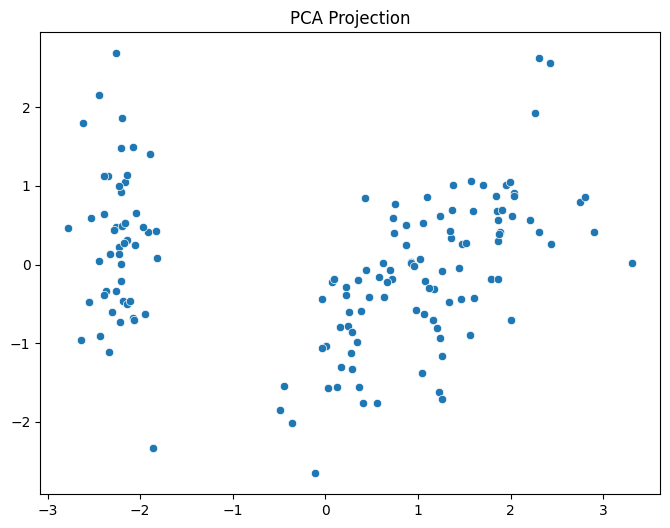

In [6]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1]
)

plt.title("PCA Projection")

plt.show()

### Step 07: Find the optimal number of clusters

In [7]:
wcss = []

for k in range(1, 21):
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

### Step 08: Visualize Elbow

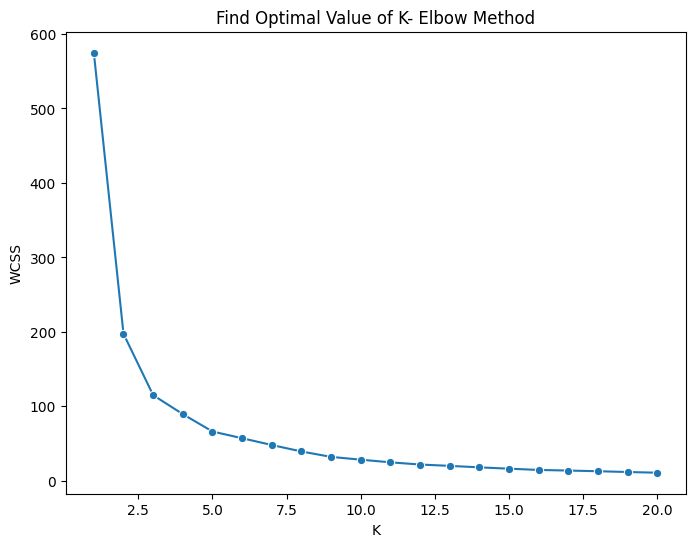

In [8]:
plt.figure(figsize=(8, 6))
sns.lineplot(
    x= range(1, 21),
    y= wcss,
    marker="o"
)

plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Find Optimal Value of K- Elbow Method")
plt.show()

### Step 09: Final Optimal values

In [9]:
kneed = KneeLocator(
    range(1, 21),
    wcss,
    curve="convex",
    direction="decreasing"
)

print(f"Optimal value of k: {kneed.elbow}")

Optimal value of k: 3


### Step 10: Train K-means on the Optimal value of `K = 3`

In [13]:
k = 3
kmeans = KMeans(
    n_clusters=k,
    n_init=15,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_pca)
centers= kmeans.cluster_centers_
print(centers)

[[ 0.57262144 -0.80720888]
 [-2.22475316  0.28892745]
 [ 1.72103664  0.60288719]]


### Step 11: Visualize KMeans's Clusters

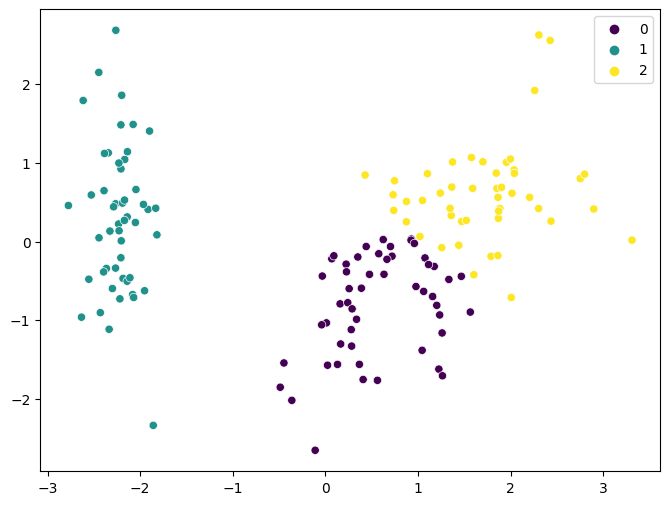

In [14]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x= X_pca[:, 0],
    y= X_pca[:, 1],
    hue= kmeans_labels,
    palette="viridis"
)

plt.show()

### Step 12: Evaluate the Quality of Clusters using `Silhouette Score`

In [16]:
score = silhouette_score(X_pca, kmeans_labels)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.5091683341538228


### Step 13: Train Allogmarative Clustering Technique

In [21]:
agg = AgglomerativeClustering(
    n_clusters=3
)

agg_labels = agg.fit_predict(X_pca)
print(agg_labels)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 1 1 1 2 1 1 1 1 1 1 1 1 2 1 1 1 1 2 1 1 1
 1 1 1 2 1 1 1 1 1 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 2 1 2 1 2 2
 1 2 1 1 2 2 2 2 1 2 1 2 1 2 2 1 1 1 2 2 2 1 1 1 2 2 2 1 2 2 2 1 2 2 2 1 2
 2 1]


### Step 14: Visualize Agglomarative Cluster Results

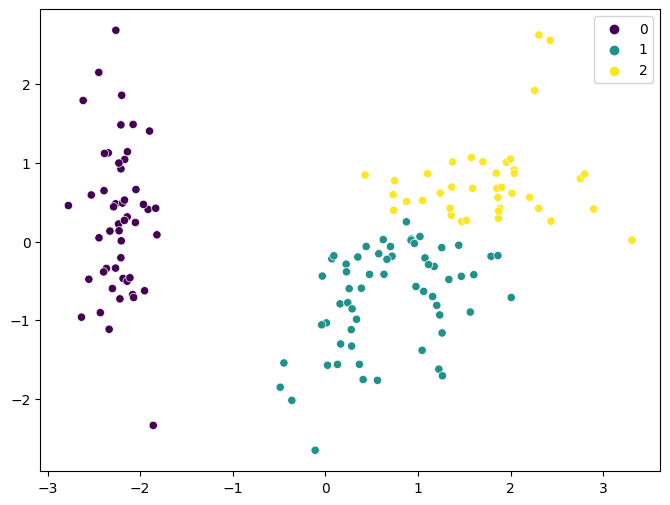

In [25]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x= X_pca[:, 0],
    y= X_pca[:, 1],
    hue= agg_labels,
    palette="viridis"
)

plt.show()

### Step 15: Calculate `Silhouette Score`

In [24]:
score = silhouette_score(X_pca, agg_labels)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.5110595988766189


### Step 16: Train DBSCAN Model

In [28]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)
print(dbscan_labels)

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1 -1 -1  1 -1 -1  1 -1  1  1  1  1  1 -1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1 -1  1  1
  1  1 -1  1 -1  1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1 -1  1  1 -1 -1 -1
  1  1 -1  1  1 -1  1  1  1 -1 -1 -1  1  1  1 -1 -1  1  1  1  1  1  1  1
  1  1  1  1 -1  1]


### Step 17: Visualize DBSCAN results

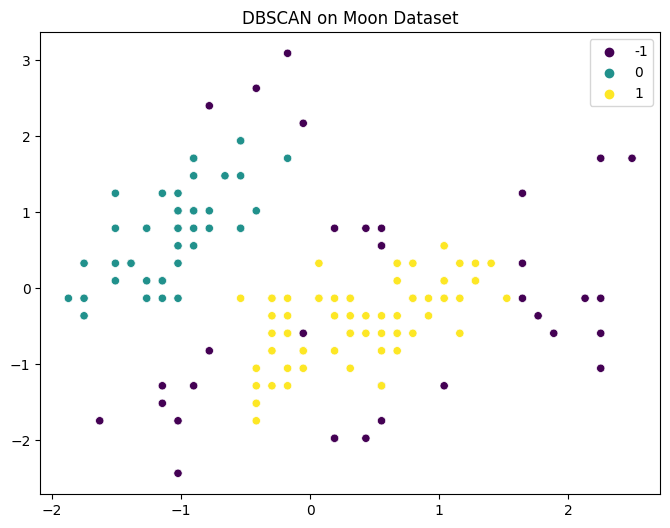

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    hue=dbscan_labels,
    palette="viridis"
)

plt.title("DBSCAN on Moon Dataset")

plt.show()

### Step 18: Calculate `Silhoutte Score` for DBSCAN

In [31]:
score = silhouette_score(X_pca, dbscan_labels)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.3703243563210543


### Conclusion

- Among the evaluated clustering algorithms, `Agglomarative Hierarchical Clustering`, achieved the highest Silhouette Score `(0.5110)`, slightly outperforming `K-Means` `(0.5091)`.
- `DBSCAN` produced a lower score, indicating less well-defined clusters on the iris dataset. 
- Therefore **`Agglomarative Clustering`** was selected as the best-performing model for this dataset based on the silhouette score. 